# LangChain Middleware

> **Key idea:** Middleware is a control layer around an agent. It allows you to inspect, modify, validate, or stop model and tool execution at specific points in the agent workflow.

## Why use middleware?

Middleware keeps cross-cutting behavior separate from the main agent logic. It is useful for:

- logging inputs, outputs, and execution time
- adding or modifying system prompts
- selecting a model dynamically
- validating or filtering responses
- handling tool errors
- enforcing permissions and safety rules
- limiting retries, tokens, or tool usage
- managing state before and after model calls

## Adding middleware to an agent

Middleware is passed to `create_agent` using the `middleware` argument:

```python
from langchain.agents import create_agent

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[get_weather],
    middleware=[my_middleware],
)
```

An agent can use more than one middleware component. They run in the order in which they are registered, so ordering can affect the final behavior.

## Main middleware hooks

### `before_model`

Runs before the model is called. It can inspect the current state, add messages, or stop the request before any model call happens.

Typical uses:

- add context or instructions
- check authentication or permissions
- reject invalid requests
- trim or summarize long message history

### `after_model`

Runs after the model returns a response. It can inspect or modify the response before the agent continues.

Typical uses:

- log model output
- validate the response
- redact sensitive information
- record token usage

### `wrap_model_call`

Wraps the model call and gives middleware control before and after the model execution. The handler must be called to continue the workflow.

```python
from langchain.agents.middleware import wrap_model_call

@wrap_model_call
def log_model_call(request, handler):
    print("Model is being called")
    response = handler(request)
    print("Model call completed")
    return response
```

This is useful when you need to measure latency, choose a model dynamically, or apply behavior around every model call.

### `wrap_tool_call`

Wraps tool execution and can observe, modify, approve, or handle tool errors.

Typical uses:

- check whether a tool call is allowed
- log tool arguments and results
- catch tool exceptions
- return a controlled error message
- add approval steps for sensitive tools

## Middleware lifecycle

A simplified agent flow looks like this:

```text
User request
    |
    v
before_model middleware
    |
    v
Model call <-> wrap_model_call middleware
    |
    v
Tool call <-> wrap_tool_call middleware
    |
    v
after_model middleware
    |
    v
Final response
```

Not every request uses a tool. When no tool is selected, the workflow can go directly from the model call to the final response.

## Middleware and agent state

Middleware receives the current request or state. This allows it to use conversation messages, runtime context, and other state values when making decisions.

Middleware should return the expected response or state update. Returning an incorrect shape can break the agent workflow.

## Middleware versus tools

- A **tool** is a capability the model can request, such as searching a database or calling an API.
- **Middleware** controls how the agent, model, and tools operate.
- Tools perform domain actions; middleware applies shared policies around those actions.

## Important revision points

- Middleware is used for cross-cutting agent behavior.
- `before_model` runs before a model call.
- `after_model` runs after a model call.
- `wrap_model_call` surrounds model execution.
- `wrap_tool_call` surrounds tool execution.
- Middleware can log, validate, modify, restrict, or stop execution.
- Middleware order matters when several middleware components are registered.
- Always preserve the expected request, response, and state structure.
- Use middleware for shared control logic instead of duplicating it inside every tool or prompt.


In [1]:
from dotenv import load_dotenv
load_dotenv()

True

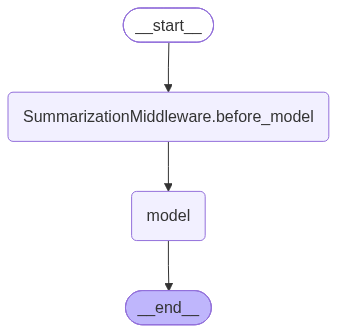

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage

agent = create_agent(
    model= "groq:openai/gpt-oss-20b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-20b",
            trigger=("messages", 10),
            keep=("messages", 4)

        )
    ],
)
agent


In [3]:
# Run with thread id
config = {
    "configurable":{
        "thread_id": "utyagi"
    }
}

# Sample questions to test the agent
questions = [
    "What is the capital of France?",
    "How many continents are there on Earth?",
    "What is the largest ocean in the world?",
    "how many countries are there in the world?",
    "how many states are there in the India?",
    "What is the capital of India?",
    "smallest country in the world?",
    "what 2+2?",
    "what is the largest desert in the world?",
    "height of Mount Everest?",
]

for question in questions:
    response = agent.invoke(
        {
            "messages":[
                HumanMessage(content=question)
            ]
        },
        config=config
    )
    print(f"Question: {question}")
    print(f"Answer: {response['messages'][-1].content}")
    print(f"Length of messages: {len(response['messages'])}")

Question: What is the capital of France?
Answer: The capital of France is **Paris**.
Length of messages: 2
Question: How many continents are there on Earth?
Answer: There are **seven** continents on Earth:

| # | Continent | Approximate Area (km²) |
|---|-----------|------------------------|
| 1 | Asia | ~44 800 000 |
| 2 | Africa | ~30 400 000 |
| 3 | North America | ~24 400 000 |
| 4 | South America | ~17 200 000 |
| 5 | Antarctica | ~14 200 000 |
| 6 | Europe | ~10 180 000 |
| 7 | Australia (Oceania) | ~8 600 000 |

These are the widely accepted continents in most geographical and educational contexts. Some older or alternative models combine Europe and Asia into “Eurasia” or merge Australia with the surrounding Pacific islands into “Oceania,” which would reduce the count, but the standard modern view lists seven distinct continents.
Length of messages: 4
Question: What is the largest ocean in the world?
Answer: The largest ocean in the world is the **Pacific Ocean**.

- **Area:** A

In [4]:
print(response['messages'][0].content)

Here is a summary of the conversation to date:

## SESSION INTENT  
The user is requesting factual geographic information, specifically the smallest country in the world.

## SUMMARY  
- **Capital of France**: Paris (provided).  
- **Number of continents**: Seven (provided with area table).  
- **Largest ocean**: Pacific Ocean (provided with details).  
- **Number of sovereign countries worldwide**: 195 (193 UN members + 2 observer states) (provided).  
- **Number of Indian states**: 28 (provided with list).  
- **Capital of India**: New Delhi (provided).  
- **Current user query**: “smallest country in the world?”

## ARTIFACTS  
None.

## NEXT STEPS  
Answer the user’s last question: provide the smallest country in the world, explain why it is the smallest, and note any other very small microstates for context.


# Token Size    

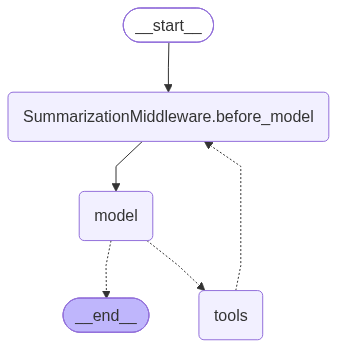

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage


@tool
def search_hotels(city: str) -> str:
    """Search hotels in a given city and return a list of hotel names."""
    return f"""Hotels in {city}: 
    Taj Hotel - 5 star, 15000/night, spa, pool, gym 
    Grand Hyatt - 5 star, 12000/night, spa, pool, gym
    Marriott - 4 star, 10000/night, spa, pool, gym"""

agent = create_agent(
    model= "groq:openai/gpt-oss-20b",
    checkpointer=InMemorySaver(),
    tools=[search_hotels],
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-20b",
            trigger=("tokens", 550),
            keep=("tokens", 200)

        )
    ],
)
agent


In [7]:
# Run with thread id
config = {
    "configurable":{
        "thread_id": "utyagi2"
    }
}

def count_tokens(messages):
    """Count the number of tokens in a list of messages."""
    return sum(len(str(message.content)) for message in messages)// 4  # Rough estimate: 1 token ~ 4 characters

# Sample questions to test the agent
cities = ["Jaipur","New Delhi","Mumbai","Bangalore","Chennai","Udaipur"]

for city in cities: 
    response = agent.invoke(
        {
            "messages":[
                HumanMessage(content=f"Find hotels in {city}?")
            ]
        },
        config=config
    )
    tokens = count_tokens(response['messages'])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(response['messages'])

Jaipur: ~317 tokens, 6 messages
[HumanMessage(content='Find hotels in Jaipur?', additional_kwargs={}, response_metadata={}, id='2f64e8b8-0ae5-41a6-b7ba-e5296f7446e3'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to find hotels in Jaipur. We have a function search_hotels that searches hotels in a given city and returns a list of hotel names. So we should call that function with city: "Jaipur".', 'tool_calls': [{'id': 'fc_275e473b-1fb9-4a6a-ae2d-033c68a76d66', 'function': {'arguments': '{"city":"Jaipur"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 133, 'total_tokens': 203, 'completion_time': 0.073082901, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.006592397, 'prompt_tokens_details': None, 'queue_time': 0.308093544, 'total_time': 0.079675298}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand',